In [ ]:
import pandas as pd

# Loading the dataset
df = pd.read_csv('/content/sample_data/Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv')


print(df.head())
print(df.info())

  transaction_id user_id  age gender  daily_screen_time_hours  \
0       TXN00001  U00001   21   Male                     3.23   
1       TXN00002  U00002   24  Other                     5.09   
2       TXN00003  U00003   31  Other                     6.06   
3       TXN00004  U00004   32  Other                     7.83   
4       TXN00005  U00005   25   Male                     9.96   

   social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
0                2.01          0.89              4.55         7.55   
1                3.81          2.24              4.44         7.66   
2                1.36          3.83              2.35         4.92   
3                5.85          1.51              3.54         8.23   
4                5.92          3.42              5.27         6.21   

   notifications_per_day  app_opens_per_day  weekend_screen_time stress_level  \
0                    248                154                 3.95       Medium   
1                    127  

In [ ]:
# Droping these values because they arent any useful
df = df.drop(['transaction_id', 'user_id', 'addiction_level'], axis=1, errors='ignore')

# Convert Gender to numeric (Male=0, Female=1, Other=2)
df['gender'] = df['gender'].astype('category').cat.codes

X = df.drop('addicted_label', axis=1)
y = df['addicted_label']

print(df.head())
print(df.info())

   age  gender  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   21       1                     3.23                2.01          0.89   
1   24       2                     5.09                3.81          2.24   
2   31       2                     6.06                1.36          3.83   
3   32       2                     7.83                5.85          1.51   
4   25       1                     9.96                5.92          3.42   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0              4.55         7.55                    248                154   
1              4.44         7.66                    127                 71   
2              2.35         4.92                     44                106   
3              3.54         8.23                    178                107   
4              5.27         6.21                    136                177   

   weekend_screen_time stress_level academic_work_impact  addicted_l

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the age bins and labels
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']

# Create the new age_group column
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

<Figure size 1200x600 with 0 Axes>

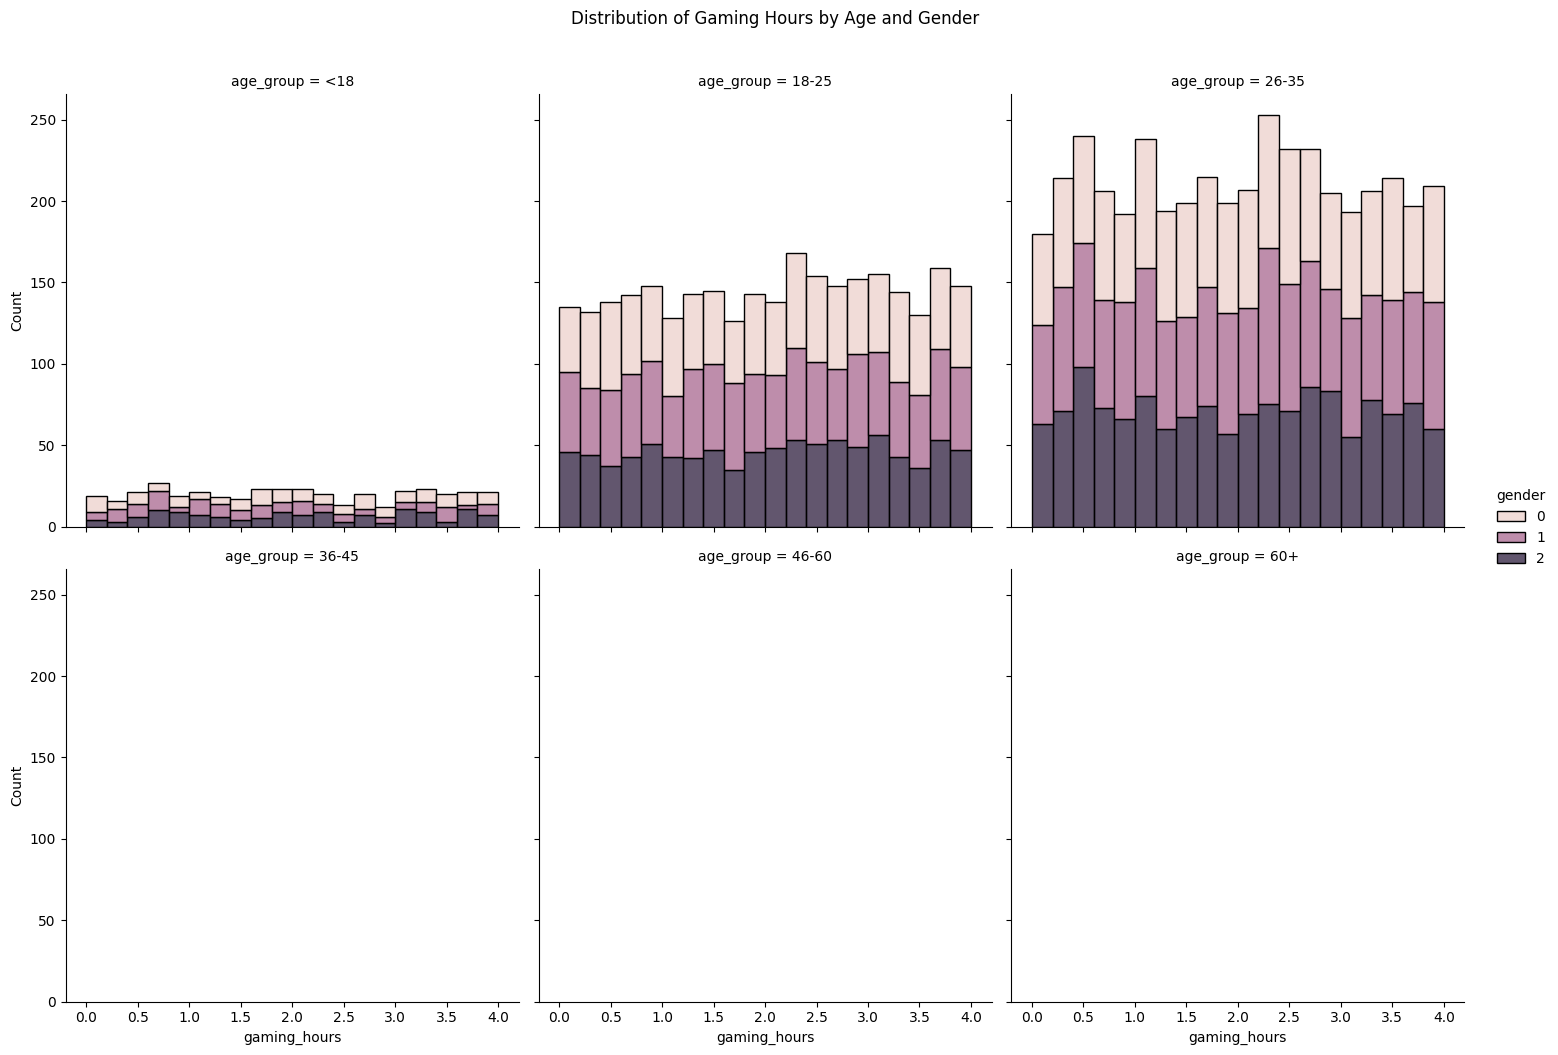

In [ ]:
plt.figure(figsize=(12, 6))
# This creates a histogram faceted by Age Group to see the difference clearly
sns.displot(data=df, x="gaming_hours", hue="gender", col="age_group",
            kind="hist", multiple="stack", col_wrap=3)

plt.suptitle("Distribution of Gaming Hours by Age and Gender", y=1.05)
plt.show()

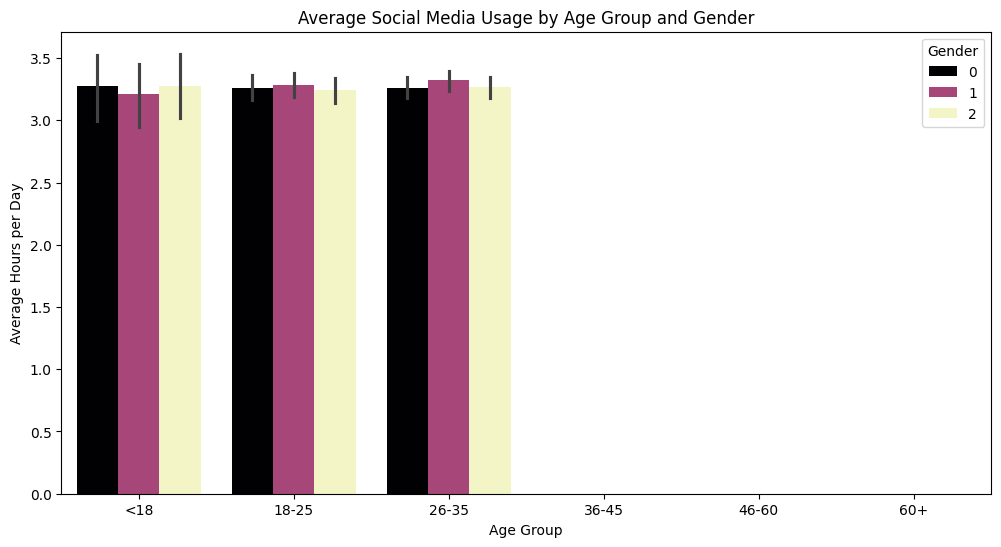

In [ ]:
plt.figure(figsize=(12, 6))
# x-axis is Age Group, y-axis is the average Social Media Hours
sns.barplot(data=df, x='age_group', y='social_media_hours', hue='gender', palette='magma')

plt.title("Average Social Media Usage by Age Group and Gender")
plt.ylabel("Average Hours per Day")
plt.xlabel("Age Group")
plt.legend(title='Gender', loc='upper right')
plt.show()

/tmp/ipykernel_10524/2839718701.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='addicted_label', y='daily_screen_time_hours', data=df, palette='Set2')


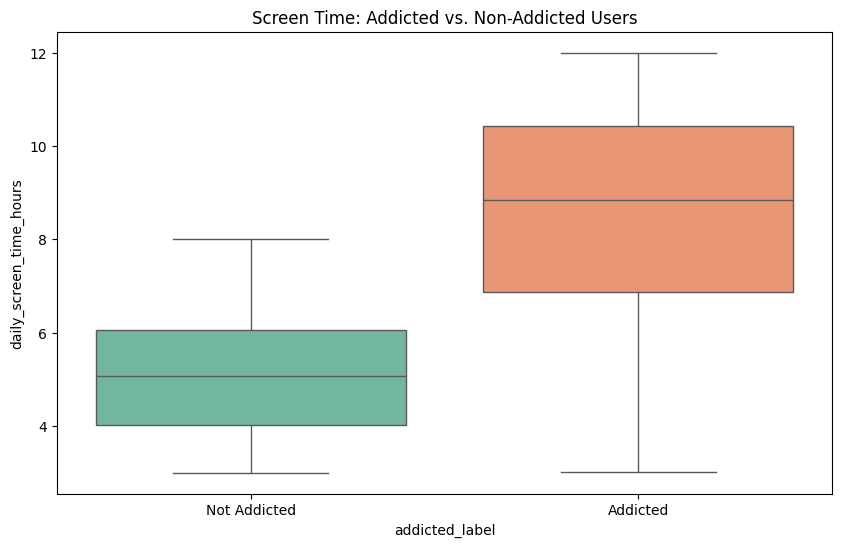

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='addicted_label', y='daily_screen_time_hours', data=df, palette='Set2')
plt.xticks([0, 1], ['Not Addicted', 'Addicted'])
plt.title('Screen Time: Addicted vs. Non-Addicted Users')
plt.show()

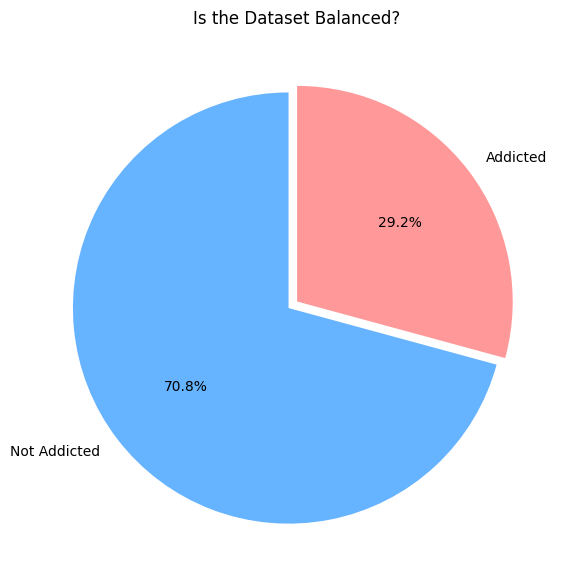

In [ ]:
import matplotlib.pyplot as plt

# Check the distribution of our target
addiction_counts = df['addicted_label'].value_counts()
labels = ['Not Addicted', 'Addicted']
colors = ['#66b3ff','#ff9999']

plt.figure(figsize=(7,7))
plt.pie(addiction_counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0))
plt.title('Is the Dataset Balanced?')
plt.show()

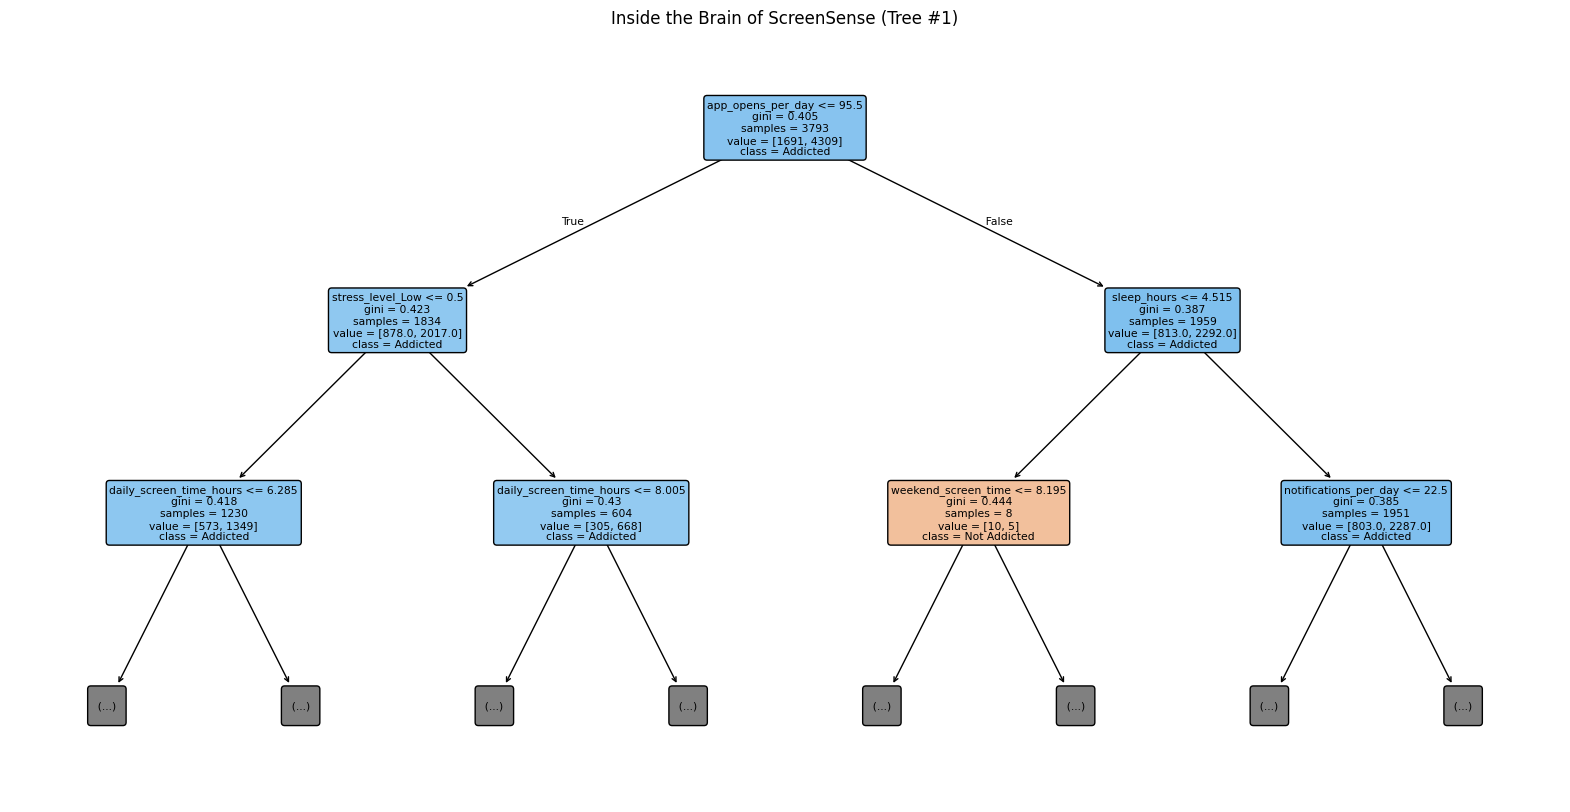

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0],
          feature_names=X.columns,
          class_names=['Not Addicted', 'Addicted'],
          filled=True, rounded=True, max_depth=2)
plt.title("Inside the Brain of ScreenSense (Tree #1)")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"--- Model Accuracy: {accuracy * 100:.2f}% ---")
print(classification_report(y_test, y_pred))

--- Model Accuracy: 92.67% ---
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       456
           1       0.96      0.93      0.95      1044

    accuracy                           0.93      1500
   macro avg       0.91      0.92      0.91      1500
weighted avg       0.93      0.93      0.93      1500

